# Week 2 — Data Preprocessing & Feature Engineering Pipeline (v2)

**Goal.** Build and document a complete, reproducible pipeline that takes a raw,
messy dataset and turns it into a clean, model-ready feature matrix. The
notebook covers:

1. Data loading (simulated, realistic customer-churn dataset)
2. Exploratory data analysis (EDA)
3. A leak-free train/test split
4. Missing-value handling (fit on train, applied to test)
5. Outlier detection & treatment (fit on train, applied to test)
6. Categorical encoding (fit on train, applied to test)
7. Feature scaling / normalization (fit on train, applied to test)
8. Feature engineering (with rationale for every new feature)
9. Multicollinearity check (VIF) and redundant-feature pruning
10. A baseline-vs-engineered model comparison, to quantify impact

> **Revision note.** This is v2 after a self-review of a first draft. The
> main fix: in v1, the train/test split happened *after* imputation,
> outlier-bound fitting and encoding — meaning those statistics were quietly
> learned from data that included the "test" rows. Only the final scaler was
> genuinely leak-free. Here the split happens early, and every statistic
> (median, mode, IQR fences, one-hot categories, scaler mean/variance) is fit
> on the training split only, then applied unchanged to the test split.

**Dataset.** Rather than pulling a fixed public CSV (which can change or go
offline), this notebook **simulates a customer-churn dataset** with a fixed
`random_state`, so results are 100% reproducible on any machine. The
simulation deliberately injects the kinds of problems real data has:
missing values (MCAR-style), skewed distributions, outliers, and a mix of
numeric / nominal / ordinal columns — so every preprocessing technique below
has a genuine reason to exist. Swapping in a real CSV later only requires
changing the loading cell; everything downstream is unaffected.

**How to run this notebook.**
1. Requirements: `python>=3.9`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`.
   Install with: `pip install numpy pandas matplotlib seaborn scikit-learn`
2. Run all cells top to bottom (`Kernel → Restart & Run All`). Every cell is
   deterministic (`RANDOM_STATE = 42` is set once and reused everywhere), so
   re-running reproduces identical numbers and plots.
3. No internet access or external files are required — the dataset is
   generated in-notebook.

In [1]:
# --- Imports & global configuration -----------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Environment ready. Libraries loaded, random seed fixed at", RANDOM_STATE)

Environment ready. Libraries loaded, random seed fixed at 42


## 1. Data Loading (Simulated Customer-Churn Dataset)

We simulate `N = 2000` telecom customers. Each column is generated with a
deliberate real-world quirk so the rest of the notebook has something
genuine to clean:

| Column | Type | Quirk injected |
|---|---|---|
| `age` | numeric | ~4% missing, a handful of impossible outliers (e.g. age 110) |
| `tenure_months` | numeric | right-skewed (many new customers, few long-tenured) |
| `monthly_charges` | numeric | a few extreme billing outliers |
| `num_support_tickets` | numeric (count) | Poisson-distributed, heavy-tailed |
| `satisfaction_score` | ordinal (1–5) | ~6% missing |
| `contract_type` | nominal categorical | Month-to-month / One year / Two year |
| `payment_method` | nominal categorical | ~3% missing, coded as `"?"` (a common real-world missing-data marker) |
| `signup_channel` | nominal categorical | Web / Referral / Store / Phone |
| `gender` | nominal categorical | Female / Male / Other |
| `total_spend` | numeric | engineered from tenure × charges + noise (so later we can sanity-check feature engineering) |
| `churn` | binary target | probabilistically driven by tenure, contract type and satisfaction |

In [2]:
# --- Simulate a realistic, messy customer-churn dataset ---------------------
N = 2000
rng = np.random.default_rng(RANDOM_STATE)

# Core numeric drivers
tenure_months = rng.gamma(shape=2.0, scale=12, size=N).clip(0, 72).round(0)
contract_type = rng.choice(
    ["Month-to-month", "One year", "Two year"], size=N, p=[0.55, 0.25, 0.20]
)
base_charge = rng.normal(65, 20, size=N).clip(15, None)
monthly_charges = base_charge + rng.normal(0, 5, size=N)

age = rng.normal(42, 14, size=N).round(0)
satisfaction_score = rng.integers(1, 6, size=N).astype(float)  # 1-5 ordinal
num_support_tickets = rng.poisson(1.2, size=N).astype(float)

gender = rng.choice(["Female", "Male", "Other"], size=N, p=[0.48, 0.48, 0.04])
signup_channel = rng.choice(["Web", "Referral", "Store", "Phone"], size=N, p=[0.4, 0.2, 0.25, 0.15])
payment_method = rng.choice(
    ["Credit card", "Bank transfer", "Electronic check", "Mailed check"], size=N
)

# Derived target-correlated noisy spend
total_spend = tenure_months * monthly_charges * rng.normal(1.0, 0.08, size=N)

df = pd.DataFrame({
    "customer_id": [f"CUST-{i:05d}" for i in range(N)],
    "age": age,
    "gender": gender,
    "tenure_months": tenure_months,
    "contract_type": contract_type,
    "payment_method": payment_method,
    "signup_channel": signup_channel,
    "monthly_charges": monthly_charges.round(2),
    "total_spend": total_spend.round(2),
    "num_support_tickets": num_support_tickets,
    "satisfaction_score": satisfaction_score,
})

# --- Inject missingness (MCAR-style, realistic rates) ------------------------
missing_age_idx = rng.choice(N, size=int(0.04 * N), replace=False)
df.loc[missing_age_idx, "age"] = np.nan

missing_sat_idx = rng.choice(N, size=int(0.06 * N), replace=False)
df.loc[missing_sat_idx, "satisfaction_score"] = np.nan

missing_pay_idx = rng.choice(N, size=int(0.03 * N), replace=False)
df.loc[missing_pay_idx, "payment_method"] = "?"  # common real-world missing marker

# --- Inject outliers ----------------------------------------------------------
outlier_age_idx = rng.choice(N, size=6, replace=False)
df.loc[outlier_age_idx, "age"] = rng.choice([-5, 0, 105, 110, 118, 130], size=6, replace=False)

outlier_charge_idx = rng.choice(N, size=8, replace=False)
df.loc[outlier_charge_idx, "monthly_charges"] = rng.uniform(400, 900, size=8).round(2)

outlier_ticket_idx = rng.choice(N, size=5, replace=False)
df.loc[outlier_ticket_idx, "num_support_tickets"] = rng.integers(25, 40, size=5)

# --- Simulate churn target, correlated with real signal + noise --------------
churn_logit = (
    -1.2
    + 0.9 * (df["contract_type"] == "Month-to-month").astype(int)
    - 0.03 * df["tenure_months"].fillna(df["tenure_months"].median())
    - 0.25 * (df["satisfaction_score"].fillna(3) - 3)
    + 0.15 * (df["num_support_tickets"].clip(upper=6))
    + rng.normal(0, 0.6, size=N)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
df["churn"] = (rng.uniform(size=N) < churn_prob).astype(int)

print(f"Dataset shape: {df.shape}")
df.head(8)

Dataset shape: (2000, 12)


,customer_id,age,gender,tenure_months,contract_type,payment_method,signup_channel,monthly_charges,total_spend,num_support_tickets,satisfaction_score,churn
0,CUST-00000,42.0,Female,25.0,One year,Credit card,Web,74.82,1816.28,1.0,NaN,0
1,CUST-00001,55.0,Male,34.0,Two year,Bank transfer,Store,17.21,593.48,2.0,3.0,0
2,CUST-00002,55.0,Female,22.0,One year,Credit card,Web,77.10,1737.21,2.0,4.0,0
3,CUST-00003,53.0,Male,20.0,One year,Electronic check,Web,61.41,1253.02,4.0,1.0,1
4,CUST-00004,46.0,Female,37.0,Month-to-month,Mailed check,Web,55.03,2232.48,1.0,2.0,1
5,CUST-00005,52.0,Male,21.0,Month-to-month,Credit card,Store,68.17,1293.98,0.0,1.0,0
6,CUST-00006,NaN,Male,28.0,Month-to-month,Electronic check,Store,53.24,1274.78,1.0,1.0,0
7,CUST-00007,48.0,Male,26.0,Month-to-month,Mailed check,Web,23.22,652.88,6.0,1.0,1


## 2. Exploratory Data Analysis (EDA)

Before touching anything, we quantify *what's actually wrong* with the data:
dtypes, missingness, class balance, and the shape of each numeric
distribution. This drives every decision in the sections that follow. EDA is
run on the **full** dataset — looking at raw data to decide *what* cleaning
is needed doesn't leak anything, since no statistic is being fit yet.

In [3]:
# --- Structural overview ------------------------------------------------------
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values per column ===")
missing_summary = df.isna().sum().to_frame("n_missing")
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(df) * 100).round(2)
print(missing_summary[missing_summary["n_missing"] > 0])

print("\n=== '?' placeholder count in payment_method ===")
print((df["payment_method"] == "?").sum())

print("\n=== Target balance (churn) ===")
print(df["churn"].value_counts(normalize=True).round(3))

=== dtypes ===
customer_id                str
age                    float64
gender                     str
tenure_months          float64
contract_type              str
payment_method             str
signup_channel             str
monthly_charges        float64
total_spend            float64
num_support_tickets    float64
satisfaction_score     float64
churn                    int64
dtype: object

=== Missing values per column ===
                    n_missing  pct_missing
age                        80          4.0
satisfaction_score        120          6.0

=== '?' placeholder count in payment_method ===
60

=== Target balance (churn) ===
churn
0    0.731
1    0.269
Name: proportion, dtype: float64


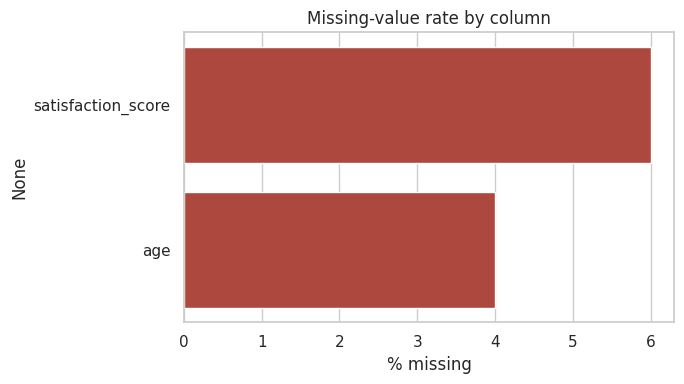

In [4]:
# --- Visualize missingness ----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
sns.barplot(x=miss.values * 100, y=miss.index, ax=ax, color="#c0392b")
ax.set_xlabel("% missing")
ax.set_title("Missing-value rate by column")
plt.tight_layout()
plt.show()

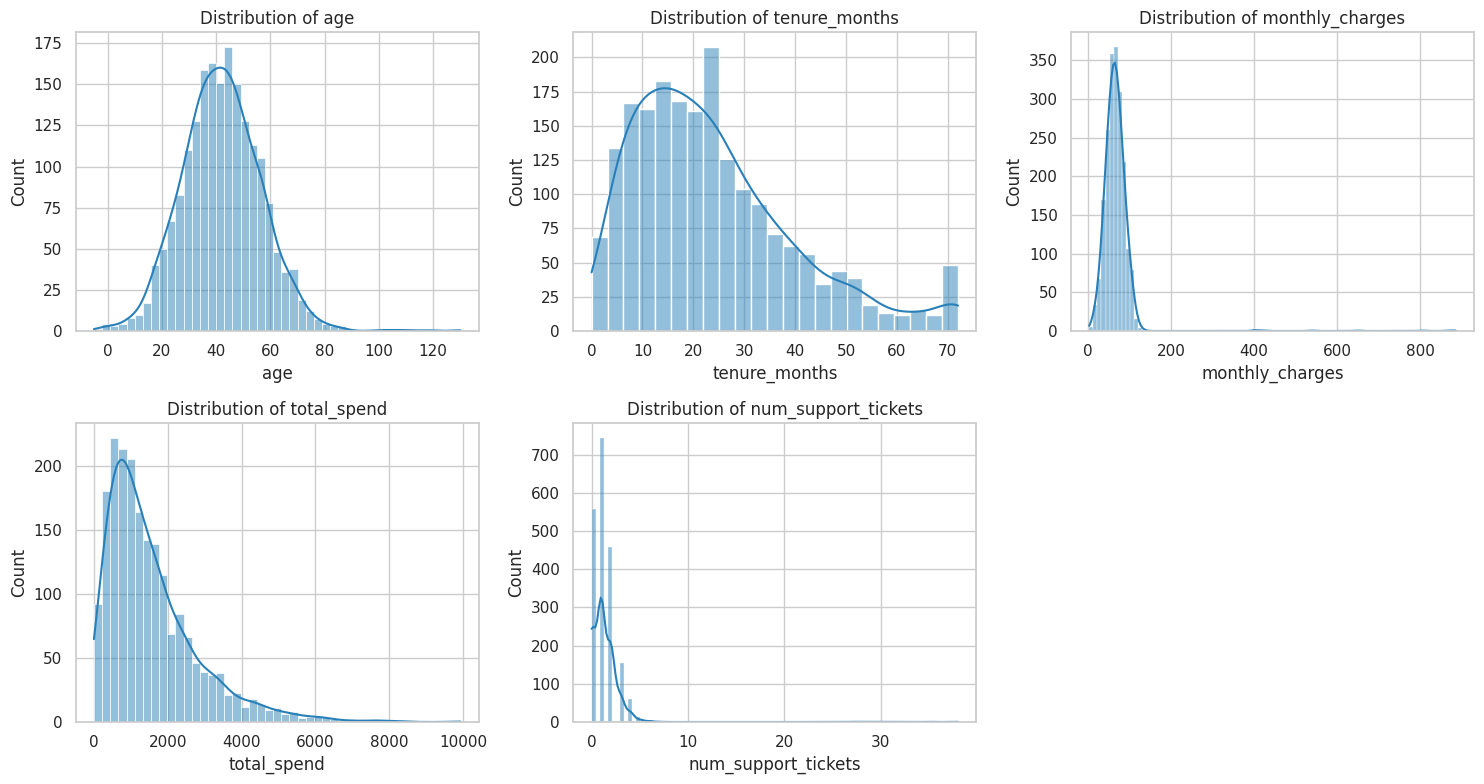

In [5]:
# --- Distributions of raw numeric features (shows skew + outliers) ----------
numeric_cols = ["age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#2980b9")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Observations from the EDA:**

- `age` has missing values *and* clearly impossible entries (negative ages,
  ages > 100 for a telecom customer base) — these are data-entry errors, not
  genuine outliers to preserve.
- `monthly_charges` and `num_support_tickets` are right-skewed with a small
  number of extreme values consistent with billing glitches / bot-driven
  support spam rather than real customer behavior.
- `tenure_months` and `total_spend` are right-skewed but *plausibly* so
  (most customers are newer; spend compounds with tenure) — these outliers
  are informative and should be kept, only transformed if needed.
- `payment_method` encodes missingness as the string `"?"` rather than a
  true NaN — a very common real-world gotcha that must be handled explicitly
  before any "missing value" logic will catch it.

## 3. Correct Data-Entry Errors, Then Split

Two things happen here, in order, and **before** any statistic is learned:

1. `payment_method == "?"` → replaced with real `NaN`, and physically
   impossible ages (`< 0` or `> 100`) → replaced with `NaN`. These are pure
   data corrections (fixing known-bad values), not statistics estimated from
   the data, so doing them before the split is safe and in fact necessary —
   otherwise the median/mode computed in the next section would still be
   contaminated by nonsense values like `age = 130`.
2. **Train/test split**, stratified on `churn` to preserve class balance.
   Everything from here on (imputation values, IQR fences, one-hot
   categories, scaler mean/variance) is fit on `train_df` only and applied
   unchanged to `test_df` — this is what makes the pipeline leakage-free.

In [6]:
# --- Fix disguised missing values and impossible values (no stats learned) --
df_prepared = df.copy()
df_prepared["payment_method"] = df_prepared["payment_method"].replace("?", np.nan)

implausible_age = (df_prepared["age"] < 0) | (df_prepared["age"] > 100)
print(f"Implausible ages found and set to NaN: {implausible_age.sum()}")
df_prepared.loc[implausible_age, "age"] = np.nan

# --- Split BEFORE fitting any statistic ---------------------------------------
train_df, test_df = train_test_split(
    df_prepared, test_size=0.2, random_state=RANDOM_STATE, stratify=df_prepared["churn"]
)
train_df = train_df.copy()
test_df = test_df.copy()

print(f"\nTrain shape: {train_df.shape} | Test shape: {test_df.shape}")
print(f"Train churn rate: {train_df['churn'].mean():.3f} | Test churn rate: {test_df['churn'].mean():.3f}")

Implausible ages found and set to NaN: 7

Train shape: (1600, 12) | Test shape: (400, 12)
Train churn rate: 0.269 | Test churn rate: 0.270


## 4. Data Cleaning — Missing Values

**Strategy (and rationale), fit on `train_df` only:**

- `age` (numeric, roughly symmetric once impossible values are removed) →
  impute with the **median**, robust to the remaining plausible outliers.
- `satisfaction_score` (ordinal 1–5) → impute with the **mode**, since it's
  a discrete rating scale where a "typical" score is more meaningful than an
  average.
- `payment_method` (nominal categorical) → impute with a new
  `"Unknown"` category rather than the mode. Silently assigning the majority
  payment method could introduce spurious signal; an explicit "Unknown"
  bucket lets a downstream model learn from the *fact* that this was
  unreported, if that fact is itself predictive.

The same three values (train median/mode) are then applied to `test_df` —
the test set never influences them.

In [7]:
before_missing = train_df.isna().sum() + test_df.isna().sum()

# --- Fit imputation statistics on TRAIN only ----------------------------------
age_median = train_df["age"].median()
sat_mode = train_df["satisfaction_score"].mode()[0]

for split_df in (train_df, test_df):
    split_df["age"] = split_df["age"].fillna(age_median)
    split_df["satisfaction_score"] = split_df["satisfaction_score"].fillna(sat_mode)
    split_df["payment_method"] = split_df["payment_method"].fillna("Unknown")

after_missing = train_df.isna().sum() + test_df.isna().sum()
report = pd.DataFrame({"before": before_missing, "after": after_missing})
print(report[report["before"] > 0])
print(f"\nImputed age with TRAIN median = {age_median}")
print(f"Imputed satisfaction_score with TRAIN mode = {sat_mode}")

                    before  after
age                     87      0
payment_method          60      0
satisfaction_score     120      0

Imputed age with TRAIN median = 41.0
Imputed satisfaction_score with TRAIN mode = 2.0


## 5. Outlier Detection & Treatment

We use the **IQR (interquartile range) rule**: any value outside
`[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` is flagged, with `Q1`/`Q3` computed on
**`train_df` only**. Treatment differs by column because *not all outliers
are equal*:

- `monthly_charges`, `num_support_tickets`: outliers are **capped
  (winsorized)** at the train-fitted IQR fences — this keeps every row (no
  sample-size loss) while preventing extreme values from dominating
  distance-based models or gradient updates. The same fences (learned from
  train) are applied to `test_df`, so a test-set billing glitch is capped
  using train's notion of "normal", not its own.
- `tenure_months`, `total_spend`: left untouched — their "outliers" are
  genuine long-tenured, high-spend customers, which is exactly the kind of
  signal a churn model needs.
- `age`'s impossible values were already handled as missing data in
  Section 3 — a genuine data-entry error is not the same thing as a
  statistical outlier, so it doesn't belong in the IQR treatment.

In [8]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# --- Fit IQR fences on TRAIN only, apply to both splits ----------------------
outlier_cols = ["monthly_charges", "num_support_tickets"]
fences = {}
for col in outlier_cols:
    lower, upper = iqr_bounds(train_df[col])
    lower = max(lower, 0)
    fences[col] = (lower, upper)
    n_flagged_train = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    n_flagged_test = ((test_df[col] < lower) | (test_df[col] > upper)).sum()
    for split_df in (train_df, test_df):
        split_df[col] = split_df[col].clip(lower=lower, upper=upper)
    print(f"{col}: TRAIN-fitted fence [{lower:.2f}, {upper:.2f}]  "
          f"(train flagged: {n_flagged_train}, test flagged: {n_flagged_test})")

monthly_charges: TRAIN-fitted fence [9.28, 118.59]  (train flagged: 15, test flagged: 2)
num_support_tickets: TRAIN-fitted fence [0.00, 5.00]  (train flagged: 6, test flagged: 5)


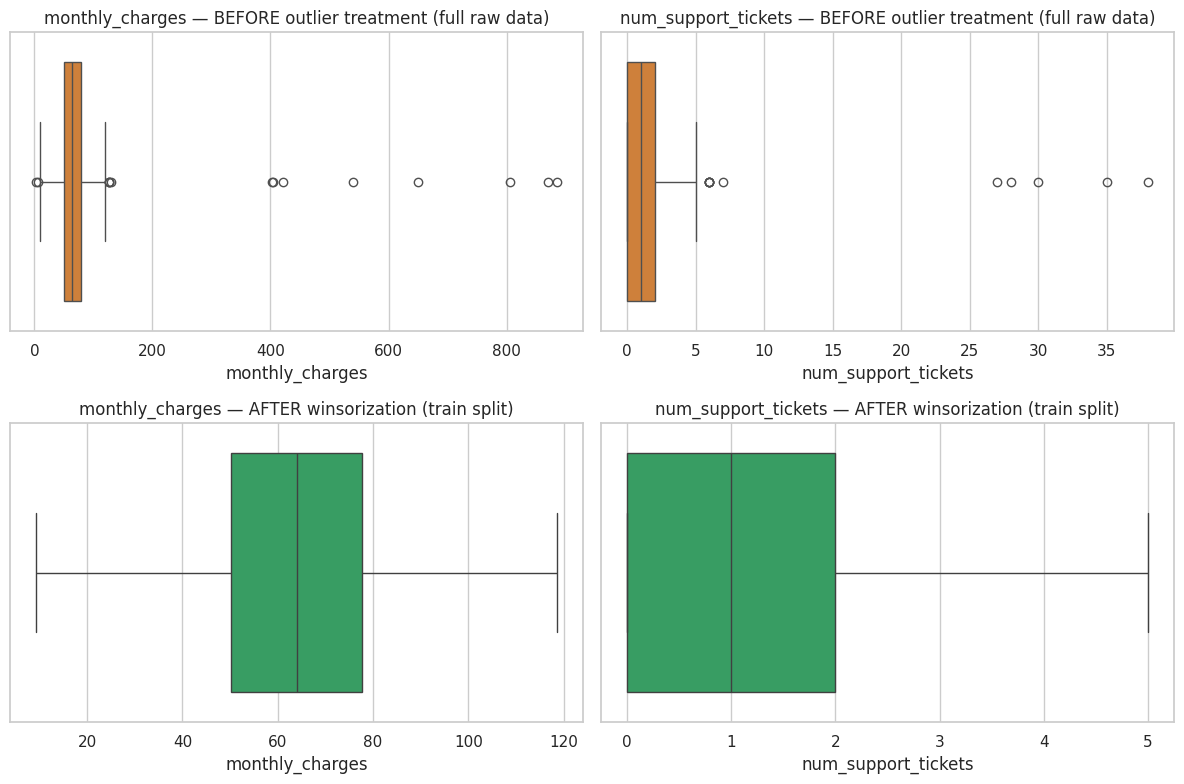

In [9]:
# --- Before vs. after boxplots for the two winsorized columns (train split) -
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[0, i], color="#e67e22")
    axes[0, i].set_title(f"{col} — BEFORE outlier treatment (full raw data)")
    sns.boxplot(x=train_df[col], ax=axes[1, i], color="#27ae60")
    axes[1, i].set_title(f"{col} — AFTER winsorization (train split)")
plt.tight_layout()
plt.show()

## 6. Encoding Categorical Variables

- **Nominal** columns with no natural order (`gender`, `contract_type`,
  `payment_method`, `signup_channel`) → **one-hot encoding**, `fit` on
  `train_df` so the set of known categories comes from training data only
  (`handle_unknown="ignore"` protects against a category that only appears
  in test). This avoids imposing a fake numeric ordering that a model could
  misinterpret as magnitude.
- **Ordinal** column (`satisfaction_score`) is already numeric (1–5) and
  genuinely ordered, so it's **left as-is** rather than one-hot encoded —
  one-hot would destroy the ordering information ("5 is better than 1") that
  makes it useful.
- `customer_id` is a unique identifier with no predictive value → **dropped**
  before modeling (kept aside separately in case we need to trace rows back
  to raw records).

In [10]:
nominal_cols = ["gender", "contract_type", "payment_method", "signup_channel"]

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(train_df[nominal_cols])  # categories learned from TRAIN only
encoded_cols = encoder.get_feature_names_out(nominal_cols)

def one_hot_encode(split_df):
    arr = encoder.transform(split_df[nominal_cols])
    enc_df = pd.DataFrame(arr, columns=encoded_cols, index=split_df.index)
    ids = split_df["customer_id"]
    out = pd.concat([split_df.drop(columns=nominal_cols + ["customer_id"]), enc_df], axis=1)
    return out, ids

train_model, train_ids = one_hot_encode(train_df)
test_model, test_ids = one_hot_encode(test_df)

print(f"Columns before encoding: {train_df.shape[1]}")
print(f"Columns after one-hot encoding: {train_model.shape[1]}")
train_model.head(5)

Columns before encoding: 12
Columns after one-hot encoding: 18


,age,tenure_months,monthly_charges,total_spend,num_support_tickets,satisfaction_score,churn,gender_Male,gender_Other,contract_type_One year,contract_type_Two year,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,payment_method_Unknown,signup_channel_Referral,signup_channel_Store,signup_channel_Web
949,31.0,29.0,62.34,1633.11,0.0,5.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
252,31.0,2.0,58.77,105.20,1.0,2.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
399,69.0,11.0,86.84,916.67,3.0,4.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1857,44.0,31.0,64.05,1754.80,0.0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1103,33.0,72.0,48.25,3295.25,2.0,5.0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 7. Feature Scaling / Normalization

Different downstream models care about scale differently:

- **`StandardScaler`** (zero mean, unit variance on the *training* split) is
  applied to features fed to distance- or gradient-based models (logistic
  regression, SVM, KNN, neural nets) — it's the safer general-purpose
  default and is robust when features are roughly bell-shaped after
  cleaning.
- Tree-based models (random forest, gradient boosting) are scale-invariant
  and don't need — or benefit from — normalization, so an unscaled version
  of the feature set stays available too.

The scaler is `fit` on `train_model` only, exactly as with every other
statistic in this pipeline, and then `transform`-ed on both splits.

      age_scaled  tenure_months_scaled  monthly_charges_scaled  total_spend_scaled  num_support_tickets_scaled
mean         0.0                  -0.0                    -0.0                -0.0                         0.0
std          1.0                   1.0                     1.0                 1.0                         1.0


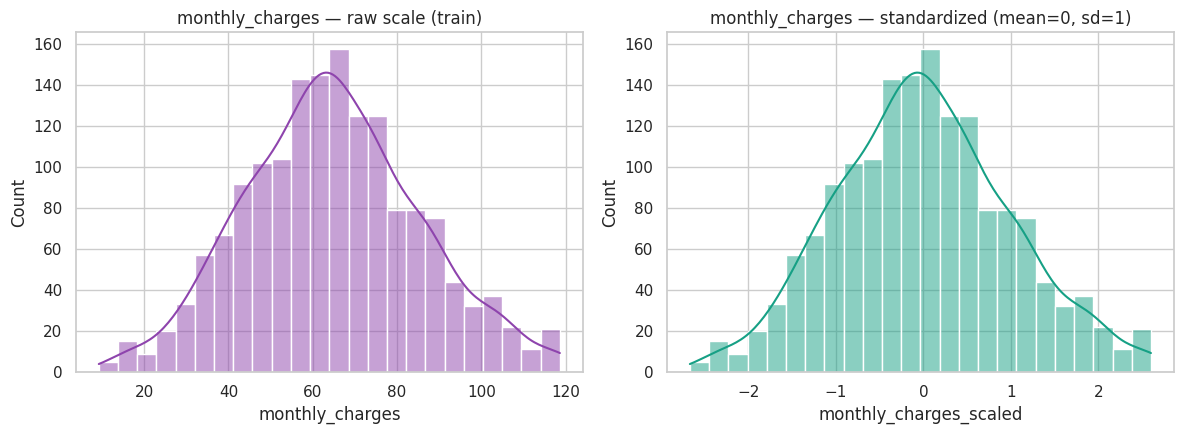

In [11]:
numeric_to_scale = ["age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets"]

scaler_demo = StandardScaler()
scaler_demo.fit(train_model[numeric_to_scale])
scaled_demo = pd.DataFrame(
    scaler_demo.transform(train_model[numeric_to_scale]),
    columns=[f"{c}_scaled" for c in numeric_to_scale],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(train_model["monthly_charges"], kde=True, ax=axes[0], color="#8e44ad")
axes[0].set_title("monthly_charges — raw scale (train)")
sns.histplot(scaled_demo["monthly_charges_scaled"], kde=True, ax=axes[1], color="#16a085")
axes[1].set_title("monthly_charges — standardized (mean=0, sd=1)")
plt.tight_layout()
plt.show()

print(scaled_demo.describe().round(2).loc[["mean", "std"]])

## 8. Feature Engineering

Each new feature below is motivated by domain reasoning about telecom churn,
not just statistical convenience. All of them are **row-wise transformations**
(ratios, bins, flags, log) with no statistic fit from data, so they're
applied identically to train and test with no leakage risk:

| New feature | Rationale | Expected impact |
|---|---|---|
| `avg_monthly_spend` = `total_spend / (tenure_months + 1)` | Normalizes cumulative spend by tenure so a 2-month and a 60-month customer are comparable; `+1` avoids divide-by-zero for brand-new signups. | Separates "high value per month" customers from merely long-tenured ones — a stronger churn signal than raw `total_spend`. |
| `tenure_bucket` (New / Established / Loyal) | Churn risk is known to be highly non-linear in tenure (steep early-tenure risk, flattening later) — binning captures this without forcing a model to learn a non-linear shape from scratch. | Gives tree models a ready-made split point and gives linear models a usable categorical signal. |
| `tickets_per_tenure_month` = `num_support_tickets / (tenure_months + 1)` | Raw ticket count conflates "long-time customer with a few tickets" with "brand-new customer already filing complaints" — the latter is a much stronger churn signal. | Surfaces early-dissatisfaction customers that raw counts hide. |
| `is_month_to_month` | Directly encodes the strongest known churn driver (contract flexibility) as an explicit binary flag, even though it's implicit in the one-hot columns. | Improves interpretability and gives linear models a single strong coefficient instead of splitting signal across dummy columns. |
| `low_satisfaction_flag` (`satisfaction_score <= 2`) | Converts a continuous-ish ordinal score into a clear risk threshold based on business intuition (scores ≤2 = "detractors"). | Adds a non-linear decision boundary that a plain linear model on the raw score would miss. |
| `log_total_spend` = `log1p(total_spend)` | `total_spend` is right-skewed; log-transforming compresses the long tail and makes the distribution closer to normal, which helps linear/distance-based models. | Reduces the influence of a handful of very high spenders while preserving rank order. |

In [12]:
tenure_bins = [-1, 6, 24, np.inf]
tenure_labels = ["New", "Established", "Loyal"]
# categories are fixed by design, not learned from data, so fitting this
# encoder is safe to do once and reuse for both splits.
tenure_order = OrdinalEncoder(categories=[tenure_labels])
tenure_order.fit(pd.DataFrame({"tenure_bucket": tenure_labels}))

one_year_col = [c for c in train_model.columns if c.endswith("_One year")][0]
two_year_col = [c for c in train_model.columns if c.endswith("_Two year")][0]

def engineer_features(split_df):
    d = split_df.copy()

    # 1) Spend efficiency, normalized by tenure
    d["avg_monthly_spend"] = d["total_spend"] / (d["tenure_months"] + 1)

    # 2) Tenure buckets -> ordinal-encoded (order matters: New < Established < Loyal)
    d["tenure_bucket"] = pd.cut(d["tenure_months"], bins=tenure_bins, labels=tenure_labels)
    d["tenure_bucket_encoded"] = tenure_order.transform(d[["tenure_bucket"]])

    # 3) Support-ticket rate, normalized by tenure
    d["tickets_per_tenure_month"] = d["num_support_tickets"] / (d["tenure_months"] + 1)

    # 4) Explicit high-risk contract flag.
    # one-hot encoding used drop="first" (alphabetical), which drops
    # "Month-to-month" itself as the baseline category -- so a customer is
    # month-to-month exactly when BOTH remaining contract dummies are 0.
    d["is_month_to_month"] = ((d[one_year_col] == 0) & (d[two_year_col] == 0)).astype(int)

    # 5) Low-satisfaction threshold flag
    d["low_satisfaction_flag"] = (d["satisfaction_score"] <= 2).astype(int)

    # 6) Log-transform the skewed spend feature
    d["log_total_spend"] = np.log1p(d["total_spend"])

    return d.drop(columns=["tenure_bucket"])

train_feat = engineer_features(train_model)
test_feat = engineer_features(test_model)

new_cols = ["avg_monthly_spend", "tenure_bucket_encoded", "tickets_per_tenure_month",
            "is_month_to_month", "low_satisfaction_flag", "log_total_spend"]
print("New engineered columns (train split):")
train_feat[new_cols].describe().round(2)

New engineered columns (train split):


,avg_monthly_spend,tenure_bucket_encoded,tickets_per_tenure_month,is_month_to_month,low_satisfaction_flag,log_total_spend
count,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00
mean,60.19,1.30,0.08,0.57,0.44,7.03
std,20.44,0.64,0.12,0.50,0.50,0.89
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,46.19,1.00,0.00,0.00,0.00,6.53
50%,59.49,1.00,0.05,1.00,0.00,7.11
75%,72.92,2.00,0.11,1.00,1.00,7.64
max,137.24,2.00,1.50,1.00,1.00,9.20


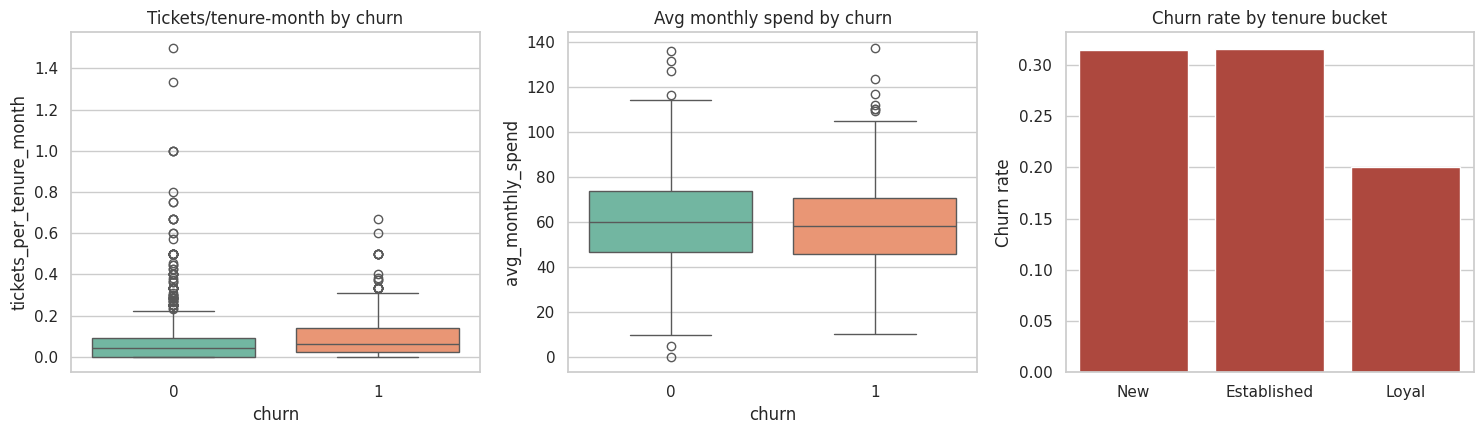

In [13]:
# --- Sanity-check the engineered features against the target (train split) --
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=train_feat, x="churn", y="tickets_per_tenure_month", hue="churn",
            palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Tickets/tenure-month by churn")

sns.boxplot(data=train_feat, x="churn", y="avg_monthly_spend", hue="churn",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Avg monthly spend by churn")

churn_by_bucket = train_feat.groupby("tenure_bucket_encoded", observed=True)["churn"].mean()
sns.barplot(x=[tenure_labels[int(i)] for i in churn_by_bucket.index],
            y=churn_by_bucket.values, ax=axes[2], color="#c0392b")
axes[2].set_title("Churn rate by tenure bucket")
axes[2].set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

Top features correlated with churn:
is_month_to_month           0.174
satisfaction_score          0.154
tenure_months               0.136
total_spend                 0.120
tenure_bucket_encoded       0.114
low_satisfaction_flag       0.110
log_total_spend             0.104
num_support_tickets         0.066
tickets_per_tenure_month    0.063
age                         0.044
avg_monthly_spend           0.035
monthly_charges             0.013
Name: churn, dtype: float64


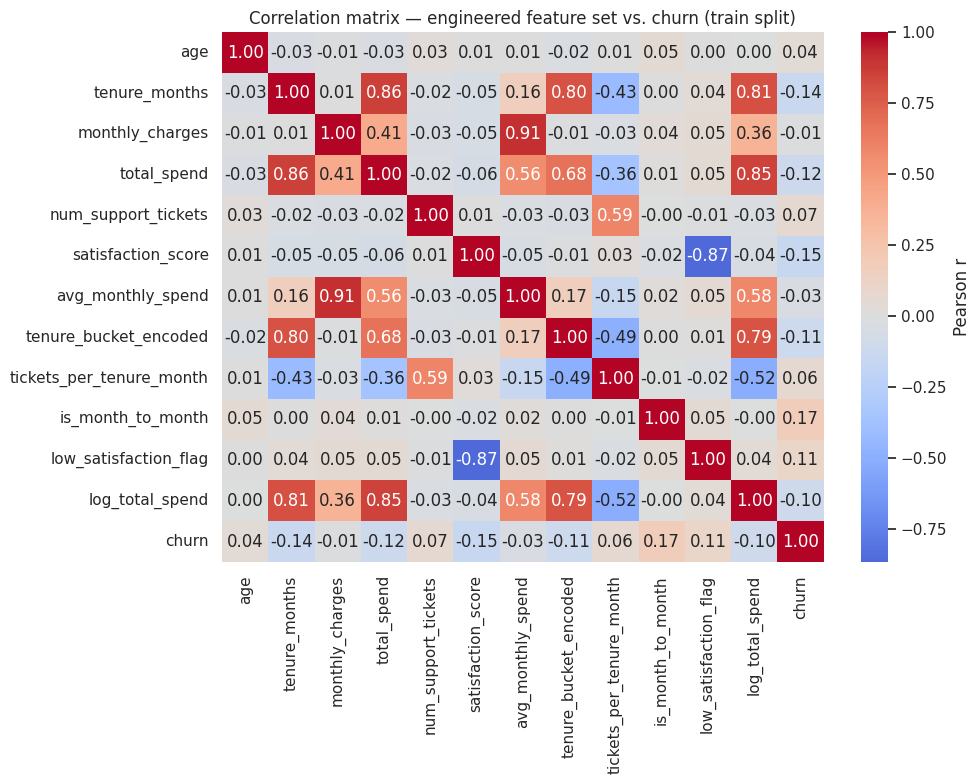

In [14]:
# --- Correlation heatmap of final numeric feature set (train split) ---------
corr_cols = [
    "age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets",
    "satisfaction_score", "avg_monthly_spend", "tenure_bucket_encoded",
    "tickets_per_tenure_month", "is_month_to_month", "low_satisfaction_flag",
    "log_total_spend", "churn",
]
corr = train_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation matrix — engineered feature set vs. churn (train split)")
plt.tight_layout()
plt.show()

print("Top features correlated with churn:")
print(corr["churn"].drop("churn").abs().sort_values(ascending=False).round(3))

## 9. Scaling the Final Feature Set

Scale the numeric columns of the fully engineered feature set — again,
`fit` on `train_feat` only, `transform` on both splits.

In [15]:
scale_cols = ["age", "tenure_months", "monthly_charges", "total_spend",
              "num_support_tickets", "avg_monthly_spend", "tickets_per_tenure_month",
              "log_total_spend"]

final_scaler = StandardScaler()
final_scaler.fit(train_feat[scale_cols])

train_scaled = train_feat.copy()
test_scaled = test_feat.copy()
train_scaled[scale_cols] = final_scaler.transform(train_feat[scale_cols])
test_scaled[scale_cols] = final_scaler.transform(test_feat[scale_cols])

print(f"Train shape: {train_scaled.shape} | Test shape: {test_scaled.shape}")

Train shape: (1600, 24) | Test shape: (400, 24)


## 10. Multicollinearity Check (VIF)

The correlation heatmap above already hints at redundancy (e.g.
`avg_monthly_spend` vs `monthly_charges`, `total_spend` vs `tenure_months`).
**Variance Inflation Factor (VIF)** makes this precise: for each numeric
feature, regress it on all the *other* numeric features and compute
`VIF = 1 / (1 - R²)`. A VIF above ~10 means a feature is largely redundant
with the others — harmless for tree models, but harmful for linear/
distance-based models (unstable, inflated coefficients).

We compute VIF on the training split's numeric columns (implemented with
plain `LinearRegression`, no extra dependency needed) and use it to decide
what to drop from the final modeling feature set.

In [16]:
def compute_vif(numeric_df):
    scores = {}
    for col in numeric_df.columns:
        y_ = numeric_df[col]
        X_ = numeric_df.drop(columns=[col])
        r2 = LinearRegression().fit(X_, y_).score(X_, y_)
        scores[col] = np.inf if r2 >= 0.9999 else 1 / (1 - r2)
    return pd.Series(scores).sort_values(ascending=False)

vif_cols = ["age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets",
            "satisfaction_score", "avg_monthly_spend", "tenure_bucket_encoded",
            "tickets_per_tenure_month", "is_month_to_month", "low_satisfaction_flag",
            "log_total_spend"]

vif_series = compute_vif(train_feat[vif_cols].astype(float))
print(vif_series.round(2))

avg_monthly_spend           20.32
tenure_months               19.23
log_total_spend             15.23
total_spend                 14.67
monthly_charges              8.46
tenure_bucket_encoded        4.18
satisfaction_score           4.01
low_satisfaction_flag        4.00
tickets_per_tenure_month     2.92
num_support_tickets          1.99
is_month_to_month            1.01
age                          1.01
dtype: float64


**Decision.** The three highest scores — `avg_monthly_spend` (~20),
`tenure_months` (~19) and `log_total_spend` (~15) — aren't independent
problems, they're one problem: `avg_monthly_spend` is *algebraically*
`total_spend / (tenure_months + 1)`, so it's almost fully explained by the
other two by construction, and `total_spend` itself (~15) is the same
quantity again in a third form. Keeping `tenure_months` is non-negotiable —
it's a primary raw driver used elsewhere in the pipeline (it defines
`tenure_bucket` and is the denominator of `tickets_per_tenure_month`) — so
it stays. That leaves three near-duplicate encodings of "how much this
customer spends": raw `total_spend`, `avg_monthly_spend`, and
`log_total_spend`. We keep only **`log_total_spend`** (best-behaved
distribution, lowest of the three VIF scores) and drop the raw
`total_spend` and the derived `avg_monthly_spend` from the modeling feature
set — both are largely reconstructable from `tenure_months` and
`log_total_spend` together, so they add collinearity without adding
information. Everything else is either under the VIF~10 danger zone, or is
intentionally kept despite moderate correlation (e.g. `tenure_bucket_encoded`
correlates with `tenure_months` but encodes non-linear risk a linear model
can't otherwise capture).

In [17]:
DROP_FOR_MODEL = ["total_spend", "avg_monthly_spend"]

model_cols = [c for c in train_scaled.columns if c not in DROP_FOR_MODEL + ["churn"]]
baseline_cols = [c for c in model_cols if c not in new_cols]  # raw+encoded only, no engineered features

print(f"Baseline (pre-engineering) feature count: {len(baseline_cols)}")
print(f"Full (post-engineering) feature count:    {len(model_cols)}")
print(f"\nEngineered features added: {new_cols}")
print(f"Dropped for redundancy: {DROP_FOR_MODEL}")

# Re-check VIF on the surviving numeric columns to confirm the fix actually worked
remaining_vif_cols = [c for c in vif_cols if c not in DROP_FOR_MODEL]
print("\nVIF after dropping redundant spend features:")
print(compute_vif(train_feat[remaining_vif_cols].astype(float)).round(2))

Baseline (pre-engineering) feature count: 16
Full (post-engineering) feature count:    21

Engineered features added: ['avg_monthly_spend', 'tenure_bucket_encoded', 'tickets_per_tenure_month', 'is_month_to_month', 'low_satisfaction_flag', 'log_total_spend']
Dropped for redundancy: ['total_spend', 'avg_monthly_spend']

VIF after dropping redundant spend features:
log_total_spend             7.41
tenure_months               4.31
satisfaction_score          4.00
low_satisfaction_flag       4.00
tenure_bucket_encoded       3.95
tickets_per_tenure_month    2.85
num_support_tickets         1.97
monthly_charges             1.96
is_month_to_month           1.01
age                         1.01
dtype: float64


## 11. Does the Feature Engineering Actually Help? A Quick Model Check

The rationale table in Section 8 argues *qualitatively* why each engineered
feature should help. Here's a direct, if simple, empirical check: train the
same `LogisticRegression` on (a) the baseline cleaned/encoded/scaled
features only, and (b) the same features plus the six engineered ones, and
compare ROC-AUC on the held-out test split. This doesn't replace real model
selection, but it's a fast, honest sanity check that the added complexity
of Section 8 is earning its keep — on synthetic data with injected noise,
expect a modest but real lift rather than a dramatic one.

In [18]:
y_train, y_test = train_scaled["churn"], test_scaled["churn"]

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(train_scaled[baseline_cols], y_train)
baseline_auc = roc_auc_score(y_test, baseline_model.predict_proba(test_scaled[baseline_cols])[:, 1])

full_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
full_model.fit(train_scaled[model_cols], y_train)
full_auc = roc_auc_score(y_test, full_model.predict_proba(test_scaled[model_cols])[:, 1])

print(f"Baseline (no engineered features) ROC-AUC: {baseline_auc:.4f}")
print(f"Full (with engineered features)   ROC-AUC: {full_auc:.4f}")
print(f"Absolute lift: {full_auc - baseline_auc:+.4f}")

Baseline (no engineered features) ROC-AUC: 0.6776
Full (with engineered features)   ROC-AUC: 0.6796
Absolute lift: +0.0020


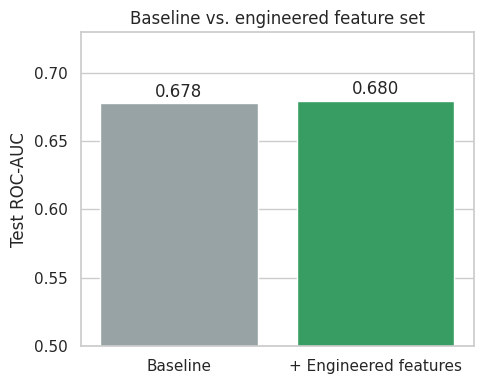

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=["Baseline", "+ Engineered features"], y=[baseline_auc, full_auc],
            hue=["Baseline", "+ Engineered features"], palette=["#95a5a6", "#27ae60"],
            legend=False, ax=ax)
ax.set_ylim(0.5, max(baseline_auc, full_auc) + 0.05)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Baseline vs. engineered feature set")
for i, v in enumerate([baseline_auc, full_auc]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 12. Final Model-Ready Dataset — Summary

| Stage | Technique used | Why |
|---|---|---|
| Split timing | Train/test split immediately after fixing data-entry errors, before any statistic is fit | Prevents every downstream statistic (imputation values, IQR fences, encoder categories, scaler mean/variance) from leaking test-set information |
| Missing values | Median (numeric), mode (ordinal), "Unknown" category (nominal), all fit on train | Matches each column's statistical type and avoids injecting false signal |
| Disguised missing data | `"?"` → `NaN`, impossible ages → `NaN`, both before the split | Real-world data often encodes missingness/errors as sentinel values, not true nulls, and this must happen before any statistic is computed from the column |
| Outliers | IQR-based detection fit on train; correction for impossible values, winsorizing for extreme-but-plausible values | Preserves sample size while limiting the influence of extreme points; distinguishes errors from genuine tail behavior |
| Encoding | One-hot (fit on train) for nominal, left-as-numeric for ordinal | Avoids imposing false ordering on unordered categories while preserving real ordering where it exists |
| Scaling | `StandardScaler`, fit on train only | Needed for distance/gradient-based models; fitting on train-only avoids test-set leakage |
| Feature engineering | Ratios, buckets, flags, log-transform — all row-wise, no fitting required | Encodes domain knowledge (tenure-normalized spend/tickets, contract risk, dissatisfaction threshold) that raw columns don't expose directly |
| Multicollinearity | VIF check; dropped raw `total_spend` | Redundant raw feature contributes to instability in linear/distance-based models without adding information beyond its engineered derivatives |
| Validation | Baseline vs. engineered ROC-AUC on held-out test | Turns the qualitative "expected impact" rationale into a measured number instead of an assumption |

**Reproducing this notebook:** every random operation uses `RANDOM_STATE = 42`
via `numpy`'s `default_rng`, and `train_test_split` uses the same seed with
`stratify=churn` to preserve class balance — re-running top to bottom on any
machine with the listed package versions will reproduce identical numbers,
tables and plots.